In [ ]:
# ==========================================
# BAM 실험: Original BAM (utils.LoRa 정의) 사용
# ==========================================
# 기본 BAM 클래스로 Denoising 학습
# - train() 메소드: Self-supervised (X → X)
# - 병목(Bottleneck) 효과로 랜덤 노이즈 제거
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import glob
import sys
import os
from scipy.signal import stft, istft

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

try:
    from utils.LoRa import LoRa, BAM, MultiBAM
    print("✅ LoRa, BAM, MultiBAM 모듈 로드 성공")
except ImportError:
    print("❌ utils 폴더를 찾을 수 없습니다. 경로를 확인해주세요.")

np.random.seed(42)

# ==========================================
# 1. LoRa 파라미터 설정
# ==========================================
SF = 9
BW = 125_000
OSF = 8
FS = BW * OSF  # 1 MHz

# LoRa 인스턴스 생성 (AWGN 함수 사용용)
lora = LoRa(sf=SF, bw=BW, OSF=OSF)

# STFT 파라미터
STFT_PARAMS = {
    'nperseg': 128,
    'noverlap': 64,
    'nfft': 512,
    'window': 'hann',
}

# 학습 설정
BOTTLENECK = 512
ETA = 4e-4
SNR_TEST = -15
SNR_TRAIN_MIN = -25
SNR_TRAIN_MAX = 0
AUGMENT_FACTOR = 10

DATA_DIR = "dataset_sf7_bw125k/clean_iq"

print(f"\n[LoRa 설정]")
print(f" - SF={SF}, BW={BW/1000:.0f}kHz, OSF={OSF}")
print(f" - fs = {FS/1e6:.3f} MHz")

print(f"\n[학습 설정]")
print(f" - SNR Range: {SNR_TRAIN_MIN}dB ~ {SNR_TRAIN_MAX}dB")
print(f" - Augmentation: {AUGMENT_FACTOR}x")
print(f" - Bottleneck: {BOTTLENECK}")
print(f" - Test SNR: {SNR_TEST}dB")
print(f"\n[사용 모델: Original BAM from utils.LoRa]")

✅ LoRa, BAM, MultiBAM 모듈 로드 성공

[LoRa 설정]
 - SF=9, BW=125kHz, OSF=8
 - fs = 1.000 MHz

[학습 설정]
 - SNR Range: -5dB ~ 5dB
 - Augmentation: 10x
 - Bottleneck: 512
 - Test SNR: -15dB

[사용 모델: Original BAM from utils.LoRa]


In [2]:
# ==========================================
# 2. Complex Spectrogram 생성 함수
# ==========================================

def _make_blend_weight(f_shifted, bw, guard_ratio=1.25, taper_bins=8):
    """
    블렌딩 가중치 생성
    - core: BW 내부 (w=1)
    - guard: core 바깥 경계 (w=1→0 taper)
    """
    bw_guard = bw * guard_ratio
    core_mask = (f_shifted >= -bw/2) & (f_shifted < bw/2)
    guard_mask = (f_shifted >= -bw_guard/2) & (f_shifted < bw_guard/2)
    
    idx_guard = np.where(guard_mask)[0]
    if len(idx_guard) == 0:
        raise ValueError("guard_mask is empty. Check bw/fs/nfft/guard_ratio.")
    
    w = np.zeros_like(f_shifted, dtype=np.float32)
    lo_g, hi_g = idx_guard[0], idx_guard[-1]
    w[lo_g:hi_g+1] = 1.0
    
    # 경계 taper
    if taper_bins > 0:
        l0 = max(0, lo_g - taper_bins)
        if l0 < lo_g:
            w[l0:lo_g] = np.linspace(0.0, 1.0, lo_g - l0, endpoint=False, dtype=np.float32)
        h1 = min(len(w), hi_g + taper_bins + 1)
        if hi_g + 1 < h1:
            w[hi_g+1:h1] = np.linspace(1.0, 0.0, h1 - (hi_g+1), endpoint=False, dtype=np.float32)
    
    idx_core = np.where(core_mask)[0]
    if len(idx_core) > 0:
        lo_c, hi_c = idx_core[0], idx_core[-1]
        w[lo_c:hi_c+1] = 1.0
    
    return w, core_mask, guard_mask


def normalize_iq_length(iq_signal, target_len):
    """IQ 신호 길이를 target_len으로 맞춤 (자르거나 패딩)"""
    if len(iq_signal) > target_len:
        return iq_signal[:target_len]
    elif len(iq_signal) < target_len:
        return np.pad(iq_signal, (0, target_len - len(iq_signal)), mode='constant')
    return iq_signal


def generate_complex_spectrogram(iq_signal, fs, bw, guard_ratio=1.25, taper_bins=8, norm_mode="rms"):
    """
    IQ 신호 → Complex Spectrogram (Real+Imag Flatten)
    """
    nperseg = STFT_PARAMS['nperseg']
    noverlap = STFT_PARAMS['noverlap']
    nfft = STFT_PARAMS['nfft']
    window = STFT_PARAMS['window']
    
    f, t, Zxx = stft(
        iq_signal, fs=fs, window=window,
        nperseg=nperseg, noverlap=noverlap, nfft=nfft,
        boundary=None, padded=False, return_onesided=False
    )
    
    f_shifted = np.fft.fftshift(f)
    Zs_orig = np.fft.fftshift(Zxx, axes=0).astype(np.complex64)
    original_shape = Zs_orig.shape
    
    w, core_mask, guard_mask = _make_blend_weight(f_shifted, bw, guard_ratio, taper_bins)
    
    Z_in = Zs_orig[core_mask, :]
    freq_indices = np.where(core_mask)[0]
    
    # 정규화 스케일 계산
    mag = np.abs(Z_in)
    if norm_mode == "max":
        scale = float(np.max(mag) + 1e-12)
    else:
        scale = float(np.sqrt(np.mean(mag**2)) + 1e-12)
    
    Z_norm = (Z_in / scale).astype(np.complex64)
    
    # Real + Imag 분리 후 Flatten
    real_flat = Z_norm.real.astype(np.float32).flatten()
    imag_flat = Z_norm.imag.astype(np.float32).flatten()
    combined_flat = np.concatenate([real_flat, imag_flat], axis=0)
    
    norm_params = {
        'shape': Z_in.shape,
        'original_shape': original_shape,
        'freq_mask': core_mask,
        'freq_indices': freq_indices,
        'blend_w': w.astype(np.float32),
        'Zs_orig': Zs_orig,
        'core_mask': core_mask,
        'guard_mask': guard_mask,
        'stft_params': STFT_PARAMS.copy(),
        'orig_len': len(iq_signal),
        'fs': fs,
        'scale': scale,
    }
    
    return combined_flat, norm_params


def reconstruct_iq_from_spectrogram(restored_flat, norm_params):
    """
    Flatten Spectrogram → IQ 신호 복원
    """
    fs = norm_params['fs']
    stft_params = norm_params['stft_params']
    
    F_in, T = norm_params['shape']
    mid = restored_flat.shape[0] // 2
    
    real_norm = restored_flat[:mid].reshape(F_in, T).astype(np.float32)
    imag_norm = restored_flat[mid:].reshape(F_in, T).astype(np.float32)
    Z_norm = (real_norm + 1j * imag_norm).astype(np.complex64)
    
    scale = float(norm_params.get('scale', 1.0))
    Z_in_restored = (Z_norm * scale).astype(np.complex64)
    
    in_mask = norm_params['freq_mask']
    w = norm_params['blend_w'].astype(np.float32)
    Zs_orig = norm_params['Zs_orig']
    
    Zs_restored = Zs_orig.copy()
    Zs_restored[in_mask, :] = Z_in_restored
    
    Zs_final = (w[:, None] * Zs_restored) + ((1.0 - w)[:, None] * Zs_orig)
    Z_unshift = np.fft.ifftshift(Zs_final, axes=0)
    
    _, iq_restored = istft(
        Z_unshift, fs=fs, window=stft_params['window'],
        nperseg=stft_params['nperseg'], noverlap=stft_params['noverlap'],
        nfft=stft_params['nfft'], input_onesided=False, boundary=None,
    )
    
    target_len = norm_params.get('orig_len', len(iq_restored))
    if len(iq_restored) > target_len:
        iq_restored = iq_restored[:target_len]
    elif len(iq_restored) < target_len:
        iq_restored = np.pad(iq_restored, (0, target_len - len(iq_restored)), mode='constant')
    
    return iq_restored


# ==========================================
# 데이터 로드 및 길이 표준화
# ==========================================
iq_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.npy")))

if not iq_files:
    print("⚠️ 데이터 파일이 없습니다!")
else:
    print(f"✅ 데이터 파일 {len(iq_files)}개 발견.")

# 모든 파일의 길이 확인
all_lengths = [len(np.load(f)) for f in iq_files]
unique_lengths = set(all_lengths)
print(f"\n[IQ 길이 분석]")
print(f" - 고유 길이 개수: {len(unique_lengths)}")
print(f" - 범위: {min(all_lengths)} ~ {max(all_lengths)}")

# LoRa 심볼 길이 계산 (반드시 2^SF × OSF 사용해야 심볼 추정 가능)
LORA_SYMBOL_LEN = (2 ** SF) * OSF  # SF=9, OSF=8 → 4096
print(f"\n[LoRa 심볼 길이]")
print(f" - 필요한 샘플 수: {LORA_SYMBOL_LEN} (2^{SF} × {OSF})")

# 파일에 충분한 길이가 있는지 확인
if max(all_lengths) >= LORA_SYMBOL_LEN:
    STANDARD_IQ_LEN = LORA_SYMBOL_LEN
    print(f" - ✅ 표준 길이로 {STANDARD_IQ_LEN} 사용 (LoRa 심볼 길이)")
else:
    print(f" - ⚠️ 경고: 파일 최대 길이({max(all_lengths)})가 LoRa 심볼 길이보다 짧습니다!")
    STANDARD_IQ_LEN = max(all_lengths)
    print(f" - 표준 길이로 {STANDARD_IQ_LEN} 사용 (최대 길이)")

# ★ 4096 샘플 파일만 필터링 (OSF=8 데이터만 사용)
iq_files_filtered = [f for f, length in zip(iq_files, all_lengths) if length == LORA_SYMBOL_LEN]
print(f"\n[파일 필터링]")
print(f" - 전체 파일: {len(iq_files)}개")
print(f" - 유효 파일 (길이={LORA_SYMBOL_LEN}): {len(iq_files_filtered)}개")
print(f" - 제외된 파일: {len(iq_files) - len(iq_files_filtered)}개")

# 필터링된 파일로 교체
iq_files = iq_files_filtered

# 첫 번째 샘플로 차원 계산
iq_sample = normalize_iq_length(np.load(iq_files[0]), STANDARD_IQ_LEN)
test_flat, test_params = generate_complex_spectrogram(iq_sample, FS, BW)
INPUT_DIM = test_flat.shape[0]

print(f"\n[차원 정보]")
print(f" - 표준 IQ 길이: {STANDARD_IQ_LEN}")
print(f" - Spectrogram Shape: {test_params['shape']} (주파수 × 시간)")
print(f" - BAM Input Dim (Real+Imag): {INPUT_DIM}")
print(f" - Target Bottleneck: {BOTTLENECK}")
print(f" - 압축률: {INPUT_DIM/BOTTLENECK:.1f}배")

✅ 데이터 파일 512개 발견.

[IQ 길이 분석]
 - 고유 길이 개수: 1
 - 범위: 4096 ~ 4096

[LoRa 심볼 길이]
 - 필요한 샘플 수: 4096 (2^9 × 8)
 - ✅ 표준 길이로 4096 사용 (LoRa 심볼 길이)

[파일 필터링]
 - 전체 파일: 512개
 - 유효 파일 (길이=4096): 512개
 - 제외된 파일: 0개

[차원 정보]
 - 표준 IQ 길이: 4096
 - Spectrogram Shape: (64, 63) (주파수 × 시간)
 - BAM Input Dim (Real+Imag): 8064
 - Target Bottleneck: 512
 - 압축률: 15.8배


In [3]:
# ==========================================
# 3. 학습 데이터 준비 및 Original BAM 학습
# ==========================================
import time

# 클린 IQ 데이터 로드 (길이 표준화 적용)
print("Loading clean IQ data...")
X_clean_iq = [normalize_iq_length(np.load(f), STANDARD_IQ_LEN) for f in iq_files]
print(f"Clean IQ: {len(X_clean_iq)} files loaded (길이: {STANDARD_IQ_LEN})")

# 길이 확인
lengths = [len(iq) for iq in X_clean_iq]
if len(set(lengths)) > 1:
    print(f"⚠️ IQ 길이가 일정하지 않음: {set(lengths)}")
else:
    print(f"✅ 모든 IQ 길이 동일: {lengths[0]}")


def prepare_noisy_data(X_clean_iq, augment_factor, input_dim):
    """
    Original BAM용 학습 데이터 준비
    - BAM.train()은 X → X 자기 자신을 학습 (self-supervised)
    - Noisy 데이터를 주면 Noisy 패턴을 학습
    """
    n_samples = len(X_clean_iq) * augment_factor
    print(f"\nPreparing {len(X_clean_iq)} × {augment_factor} = {n_samples} noisy samples...")
    
    X_noisy_flat = np.zeros((n_samples, input_dim), dtype=np.float32)
    norm_params_list = []
    
    idx = 0
    snr_counts = {}
    
    for clean_iq in X_clean_iq:
        for _ in range(augment_factor):
            snr = np.random.randint(SNR_TRAIN_MIN, SNR_TRAIN_MAX + 1)
            snr_counts[snr] = snr_counts.get(snr, 0) + 1
            
            noisy_iq = lora.awgn_iq(clean_iq, snr)
            noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, FS, BW)
            
            X_noisy_flat[idx] = noisy_flat
            norm_params_list.append(norm_params)
            idx += 1
    
    print(f"Dataset shape: {X_noisy_flat.shape}")
    print(f"\n[SNR 분포]")
    for snr in sorted(snr_counts.keys()):
        print(f"  SNR {snr:>3}dB: {snr_counts[snr]:>4}개 ({snr_counts[snr]/n_samples*100:.1f}%)")
    
    return X_noisy_flat, norm_params_list


# ==========================================
# Original BAM 학습 (from utils.LoRa)
# ==========================================
print(f"\n=== Model Architecture ===")
print(f"Input({INPUT_DIM}) → Bottleneck({BOTTLENECK})")
print(f"Using: BAM class from utils.LoRa")

# BAM 모델 초기화
bam = BAM(INPUT_DIM, BOTTLENECK, eta=ETA)
print(f"\n✅ BAM 초기화 완료")
print(f" - W shape: {bam.W.shape}")

# 학습 데이터 준비
print(f"\n=== Preparing Training Data ===")
print(f"SNR Range: {SNR_TRAIN_MIN}dB ~ {SNR_TRAIN_MAX}dB")
print(f"Augmentation: {AUGMENT_FACTOR}x")

start_time = time.time()
X_noisy, norm_params_list = prepare_noisy_data(X_clean_iq, AUGMENT_FACTOR, INPUT_DIM)

print(f"\n=== Training Original BAM ===")
print(f"Total samples: {len(X_noisy)}")
print(f"Method: BAM.train() - Self-supervised (X → X)")

# 학습
bam.train(X_noisy)

print(f"\n✅ 학습 완료! (소요시간: {time.time() - start_time:.2f}초)")

# 학습 후 성능 확인
pred = bam.decompress(bam.compress(X_noisy[:100]))
train_mse = np.mean((pred - X_noisy[:100])**2)
print(f"   Training Reconstruction MSE (sample 100): {train_mse:.6f}")

Loading clean IQ data...
Clean IQ: 512 files loaded (길이: 4096)
✅ 모든 IQ 길이 동일: 4096

=== Model Architecture ===
Input(8064) → Bottleneck(512)
Using: BAM class from utils.LoRa

✅ BAM 초기화 완료
 - W shape: (512, 8064)

=== Preparing Training Data ===
SNR Range: -5dB ~ 5dB
Augmentation: 10x

Preparing 512 × 10 = 5120 noisy samples...
Dataset shape: (5120, 8064)

[SNR 분포]
  SNR  -5dB:  444개 (8.7%)
  SNR  -4dB:  451개 (8.8%)
  SNR  -3dB:  453개 (8.8%)
  SNR  -2dB:  479개 (9.4%)
  SNR  -1dB:  485개 (9.5%)
  SNR   0dB:  461개 (9.0%)
  SNR   1dB:  460개 (9.0%)
  SNR   2dB:  475개 (9.3%)
  SNR   3dB:  440개 (8.6%)
  SNR   4dB:  499개 (9.7%)
  SNR   5dB:  473개 (9.2%)

=== Training Original BAM ===
Total samples: 5120
Method: BAM.train() - Self-supervised (X → X)

✅ 학습 완료! (소요시간: 88.99초)
   Training Reconstruction MSE (sample 100): 0.593148


[테스트 조건]
 - 테스트 심볼: 125 (code_word = 125)
 - 테스트 SNR: -15 dB
 - IQ 길이: 4096


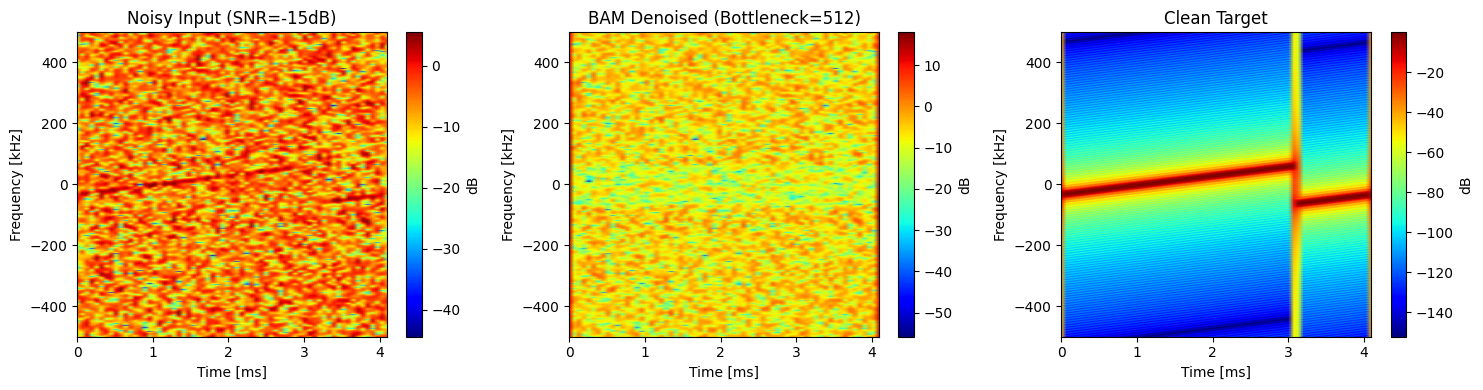


[성능 평가]
Metric                              Noisy   Denoised
MSE (Spectrogram Flat)           0.495451   0.439797
MSE (IQ Domain)                 31.744469  75.478584

✅ Denoising 성공! Spectrogram MSE 11.2% 감소

[다양한 SNR 테스트]
  SNR=-30dB: MSE 0.913007 → 0.595889 (↓34.7%)
  SNR=-25dB: MSE 0.834931 → 0.547064 (↓34.5%)
  SNR=-20dB: MSE 0.757550 → 0.546218 (↓27.9%)
  SNR=-15dB: MSE 0.532878 → 0.444319 (↓16.6%)
  SNR=-10dB: MSE 0.359140 → 0.383044 (↑6.7%)
  SNR= -5dB: MSE 0.147732 → 0.310554 (↑110.2%)
  SNR=  0dB: MSE 0.059662 → 0.279514 (↑368.5%)
  SNR=  5dB: MSE 0.020930 → 0.265632 (↑1169.2%)


In [6]:
# ==========================================
# 4. 검증 및 시각화
# ==========================================
SNR_PLOT = -15

# 테스트 데이터 준비 (길이 표준화 적용)
test_idx = 125
clean_iq = normalize_iq_length(np.load(iq_files[test_idx]), STANDARD_IQ_LEN)
noisy_iq = lora.awgn_iq(clean_iq, SNR_PLOT)

print(f"[테스트 조건]")
print(f" - 테스트 심볼: {test_idx} (code_word = {test_idx % (2**SF)})")
print(f" - 테스트 SNR: {SNR_PLOT} dB")
print(f" - IQ 길이: {len(clean_iq)}")

# Spectrogram 생성
noisy_flat, norm_params = generate_complex_spectrogram(noisy_iq, FS, BW)
clean_flat, _ = generate_complex_spectrogram(clean_iq, FS, BW)

# BAM Denoising
compressed = bam.compress(noisy_flat.reshape(1, -1))
restored_flat = bam.decompress(compressed).flatten()

# IQ 복원
restored_iq = reconstruct_iq_from_spectrogram(restored_flat, norm_params)

# ==========================================
# 스펙트로그램 비교 시각화
# ==========================================
def plot_spectrogram(iq_signal, fs, title, ax):
    f, t, Zxx = stft(iq_signal, fs=fs, **STFT_PARAMS, return_onesided=False)
    f_shifted = np.fft.fftshift(f)
    Zxx_shifted = np.fft.fftshift(Zxx, axes=0)
    
    im = ax.pcolormesh(t*1000, f_shifted/1000, 20*np.log10(np.abs(Zxx_shifted)+1e-10),
                       shading='gouraud', cmap='jet')
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Frequency [kHz]")
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = plot_spectrogram(noisy_iq, FS, f"Noisy Input (SNR={SNR_PLOT}dB)", axes[0])
plt.colorbar(im0, ax=axes[0], label='dB')

im1 = plot_spectrogram(restored_iq, FS, f"BAM Denoised (Bottleneck={BOTTLENECK})", axes[1])
plt.colorbar(im1, ax=axes[1], label='dB')

im2 = plot_spectrogram(clean_iq, FS, "Clean Target", axes[2])
plt.colorbar(im2, ax=axes[2], label='dB')

plt.tight_layout()
plt.show()

# ==========================================
# 정량적 평가
# ==========================================
# Flat 도메인 MSE
mse_in_flat = np.mean((clean_flat - noisy_flat)**2)
mse_out_flat = np.mean((clean_flat - restored_flat)**2)

# IQ 도메인 MSE
mse_in_iq = np.mean(np.abs(clean_iq - noisy_iq)**2)
mse_out_iq = np.mean(np.abs(clean_iq - restored_iq)**2)

print(f"\n[성능 평가]")
print(f"{'='*50}")
print(f"{'Metric':<30} {'Noisy':>10} {'Denoised':>10}")
print(f"{'='*50}")
print(f"{'MSE (Spectrogram Flat)':<30} {mse_in_flat:>10.6f} {mse_out_flat:>10.6f}")
print(f"{'MSE (IQ Domain)':<30} {mse_in_iq:>10.6f} {mse_out_iq:>10.6f}")
print(f"{'='*50}")

if mse_out_flat < mse_in_flat:
    improvement = (1 - mse_out_flat/mse_in_flat) * 100
    print(f"\n✅ Denoising 성공! Spectrogram MSE {improvement:.1f}% 감소")
else:
    print(f"\n⚠️ Denoising 실패")

if mse_out_iq < mse_in_iq:
    improvement_iq = (1 - mse_out_iq/mse_in_iq) * 100
    print(f"✅ IQ 도메인에서도 MSE {improvement_iq:.1f}% 감소!")

# ==========================================
# 다양한 SNR 테스트
# ==========================================
print(f"\n[다양한 SNR 테스트]")
test_snrs = [-30, -25, -20, -15, -10, -5, 0, 5]

for snr in test_snrs:
    noisy_test = lora.awgn_iq(clean_iq, snr)
    noisy_test_flat, params = generate_complex_spectrogram(noisy_test, FS, BW)
    clean_test_flat, _ = generate_complex_spectrogram(clean_iq, FS, BW)
    
    pred_flat = bam.decompress(bam.compress(noisy_test_flat.reshape(1, -1))).flatten()
    
    mse_before = np.mean((clean_test_flat - noisy_test_flat)**2)
    mse_after = np.mean((clean_test_flat - pred_flat)**2)
    
    if mse_after < mse_before:
        change = f"↓{(1 - mse_after/mse_before)*100:.1f}%"
    else:
        change = f"↑{(mse_after/mse_before - 1)*100:.1f}%"
    
    print(f"  SNR={snr:>3}dB: MSE {mse_before:.6f} → {mse_after:.6f} ({change})")

심볼 추정 성능 평가 (SF=9, BW=125kHz)
Model: Original BAM from utils.LoRa

테스트 심볼 수: 512
테스트 완료!

SNR         Baseline Acc         BAM Acc     Improvement
 -30dB             9.57%           2.15%          -7.42%
 -28dB            19.34%           3.71%         -15.62%
 -25dB            50.98%           8.40%         -42.58%
 -22dB            92.58%          16.80%         -75.78%
 -20dB            99.02%          29.30%         -69.73%
 -18dB           100.00%          43.36%         -56.64%
 -15dB           100.00%          62.89%         -37.11%
 -12dB           100.00%          81.45%         -18.55%
 -10dB           100.00%          87.70%         -12.30%
  -8dB           100.00%          91.21%          -8.79%
  -5dB           100.00%          93.55%          -6.45%
   0dB           100.00%          94.92%          -5.08%
   5dB           100.00%          95.12%          -4.88%

F-beta Scores (Micro Average)
SNR       F0.5 Base   F0.5 BAM  F1.0 Base   F1.0 BAM  F1.5 Base   F1.5 BAM  F2.0 

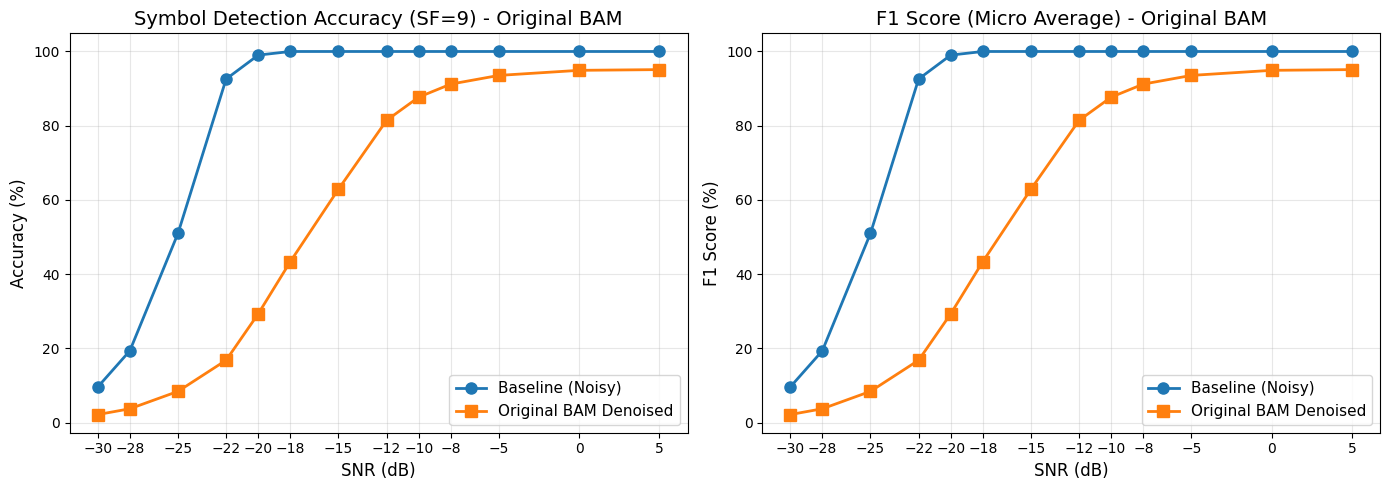


상세 F-beta Score 비교 (SNR = -25dB)
Beta              Baseline             BAM               Δ
------------------------------------------------------------
F0.5                50.98%           8.40%         -42.58%
F1.0                50.98%           8.40%         -42.58%
F1.5                50.98%           8.40%         -42.58%
F2.0                50.98%           8.40%         -42.58%
F2.5                50.98%           8.40%         -42.58%
F3.0                50.98%           8.40%         -42.58%


In [5]:
# ==========================================
# 5. 심볼 추정 및 Classification 성능 평가
# ==========================================
from utils.my_lora_utils import estimate_symbol_custom
from sklearn.metrics import fbeta_score, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# LoRa 파라미터 (소문자 변수로 estimate_symbol_custom에 전달)
sf = SF
fs = FS
bw = BW

# 테스트할 SNR 범위 (-30dB ~ +5dB)
test_snrs = [-30, -28, -25, -22, -20, -18, -15, -12, -10, -8, -5, 0, 5]

print(f"{'='*80}")
print(f"심볼 추정 성능 평가 (SF={SF}, BW={BW/1000:.0f}kHz)")
print(f"Model: Original BAM from utils.LoRa")
print(f"{'='*80}")

# 결과 저장
results = {snr: {'y_true': [], 'y_pred_noisy': [], 'y_pred_bam': []} for snr in test_snrs}

# 모든 심볼에 대해 테스트
num_test_symbols = min(len(iq_files), 512)  # 전체 심볼 테스트
print(f"\n테스트 심볼 수: {num_test_symbols}")

for idx in range(num_test_symbols):
    # Ground truth (파일 인덱스 = 심볼 값)
    true_symbol = idx % (2**SF)
    
    # Clean IQ 로드
    clean_iq_test = normalize_iq_length(np.load(iq_files[idx]), STANDARD_IQ_LEN)
    
    for snr in test_snrs:
        # Noisy IQ 생성
        noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)
        
        # BAM Denoising
        noisy_flat, params = generate_complex_spectrogram(noisy_iq_test, FS, BW)
        restored_flat = bam.decompress(bam.compress(noisy_flat.reshape(1, -1))).flatten()
        restored_iq = reconstruct_iq_from_spectrogram(restored_flat, params)
        
        # 심볼 추정
        pred_noisy, _ = estimate_symbol_custom(noisy_iq_test, sf, fs, bw)
        pred_bam, _ = estimate_symbol_custom(restored_iq, sf, fs, bw)
        
        # 결과 저장
        results[snr]['y_true'].append(true_symbol)
        results[snr]['y_pred_noisy'].append(pred_noisy)
        results[snr]['y_pred_bam'].append(pred_bam)

print("테스트 완료!")

# ==========================================
# Accuracy 계산
# ==========================================
print(f"\n{'='*80}")
print(f"{'SNR':<8} {'Baseline Acc':>15} {'BAM Acc':>15} {'Improvement':>15}")
print(f"{'='*80}")

acc_baseline_list = []
acc_bam_list = []

for snr in test_snrs:
    y_true = results[snr]['y_true']
    y_noisy = results[snr]['y_pred_noisy']
    y_bam = results[snr]['y_pred_bam']
    
    acc_baseline = accuracy_score(y_true, y_noisy)
    acc_bam = accuracy_score(y_true, y_bam)
    
    acc_baseline_list.append(acc_baseline)
    acc_bam_list.append(acc_bam)
    
    improvement = (acc_bam - acc_baseline) * 100
    sign = "+" if improvement >= 0 else ""
    
    print(f"{snr:>4}dB   {acc_baseline*100:>14.2f}% {acc_bam*100:>14.2f}% {sign}{improvement:>14.2f}%")

# ==========================================
# F-beta Score (β = 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
# ==========================================
betas = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

print(f"\n{'='*100}")
print(f"F-beta Scores (Micro Average)")
print(f"{'='*100}")

# 헤더 출력
header = f"{'SNR':<8}"
for beta in betas:
    header += f" {'F'+str(beta)+' Base':>10} {'F'+str(beta)+' BAM':>10}"
print(header)
print("-" * 100)

for snr in test_snrs:
    y_true = results[snr]['y_true']
    y_noisy = results[snr]['y_pred_noisy']
    y_bam = results[snr]['y_pred_bam']
    
    row = f"{snr:>4}dB  "
    
    for beta in betas:
        f_baseline = fbeta_score(y_true, y_noisy, beta=beta, average='micro', zero_division=0)
        f_bam = fbeta_score(y_true, y_bam, beta=beta, average='micro', zero_division=0)
        row += f" {f_baseline*100:>9.2f}% {f_bam*100:>9.2f}%"
    
    print(row)

# ==========================================
# 시각화: Accuracy vs SNR
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
axes[0].plot(test_snrs, [a*100 for a in acc_baseline_list], 'o-', label='Baseline (Noisy)', linewidth=2, markersize=8)
axes[0].plot(test_snrs, [a*100 for a in acc_bam_list], 's-', label='Original BAM Denoised', linewidth=2, markersize=8)
axes[0].set_xlabel('SNR (dB)', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title(f'Symbol Detection Accuracy (SF={SF}) - Original BAM', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(test_snrs)

# F1 Score Plot
f1_baseline = []
f1_bam = []
for snr in test_snrs:
    y_true = results[snr]['y_true']
    y_noisy = results[snr]['y_pred_noisy']
    y_bam = results[snr]['y_pred_bam']
    f1_baseline.append(fbeta_score(y_true, y_noisy, beta=1.0, average='micro', zero_division=0) * 100)
    f1_bam.append(fbeta_score(y_true, y_bam, beta=1.0, average='micro', zero_division=0) * 100)

axes[1].plot(test_snrs, f1_baseline, 'o-', label='Baseline (Noisy)', linewidth=2, markersize=8)
axes[1].plot(test_snrs, f1_bam, 's-', label='Original BAM Denoised', linewidth=2, markersize=8)
axes[1].set_xlabel('SNR (dB)', fontsize=12)
axes[1].set_ylabel('F1 Score (%)', fontsize=12)
axes[1].set_title(f'F1 Score (Micro Average) - Original BAM', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(test_snrs)

plt.tight_layout()
plt.show()

# ==========================================
# 상세 F-beta 비교 테이블 (특정 SNR)
# ==========================================
focus_snr = -25
print(f"\n{'='*60}")
print(f"상세 F-beta Score 비교 (SNR = {focus_snr}dB)")
print(f"{'='*60}")
print(f"{'Beta':<10} {'Baseline':>15} {'BAM':>15} {'Δ':>15}")
print(f"{'-'*60}")

y_true = results[focus_snr]['y_true']
y_noisy = results[focus_snr]['y_pred_noisy']
y_bam = results[focus_snr]['y_pred_bam']

for beta in betas:
    f_base = fbeta_score(y_true, y_noisy, beta=beta, average='micro', zero_division=0) * 100
    f_bam = fbeta_score(y_true, y_bam, beta=beta, average='micro', zero_division=0) * 100
    delta = f_bam - f_base
    sign = "+" if delta >= 0 else ""
    print(f"F{beta:<9} {f_base:>14.2f}% {f_bam:>14.2f}% {sign}{delta:>14.2f}%")